## <b><u> Fil Rouge : Customer Churn Analysis ##

### <b>1. Compréhension du problème métier : ##

#### <u>Contexte : </u>
Dans le secteur des télécommunications, la fidélisation des clients représente un enjeu stratégique majeur. Le départ d'un client, appelé « churn », engendre une perte de revenus et nécessite des coûts supplémentaires pour acquérir de nouveaux clients.

L'objectif de cette étude est d'identifier les facteurs influençant le churn afin d'aider l'entreprise à mettre en place des actions de rétention ciblées.

#### <u>Objectifs de l'analyse : </u>
Cette étude vise à répondre aux questions suivantes :

    Quel est le taux de churn de l'entreprise ?
    Quels profils de clients sont les plus susceptibles de quitter l'entreprise ?
    L'ancienneté du client influence-t-elle le churn ?
    Le type de contrat a-t-il un impact sur la fidélisation ?
    Quels services permettent de réduire le risque de départ ?
    Quelles recommandations peuvent être proposées pour améliorer la rétention des clients ?

### <b>2. Compréhension des données : ##


#### <u>Présentation du jeu de données : </u>
Le jeu de données utilisé provient de Kaggle et contient des informations sur les clients d'une entreprise de télécommunications.

Chaque ligne représente un client et chaque colonne décrit une caractéristique du client ou de son abonnement.

#### <u> Aperçu des données : </u>

##### Bibliothèques : ##

In [26]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

##### Cette première visualisation permet de comprendre la structure générale du jeu de données ainsi que les différentes variables disponibles.

In [27]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Join Date,Churn Date
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,2019-12-03,2020-01-28
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,2019-12-03,2020-01-23
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,2019-06-06,2020-01-05
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,2017-10-14,2019-10-26
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,2016-01-23,2019-12-04


#### <u> Structure des données :</u>

In [28]:
#Identifier le nombre de lignes et colonnes du jeu de données
df.shape

(7043, 35)

In [29]:
#Identifier les types de variables ainsi que la présence éventuelle de valeurs manquantes.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         7043 non-null   str           
 1   Count              7043 non-null   int64         
 2   Country            7043 non-null   str           
 3   State              7043 non-null   str           
 4   City               7043 non-null   str           
 5   Zip Code           7043 non-null   int64         
 6   Lat Long           7043 non-null   str           
 7   Latitude           7043 non-null   float64       
 8   Longitude          7043 non-null   float64       
 9   Gender             7043 non-null   str           
 10  Senior Citizen     7043 non-null   str           
 11  Partner            7043 non-null   str           
 12  Dependents         7043 non-null   str           
 13  Tenure Months      7043 non-null   int64         
 14  Phone Service      

#### <u>Statistiques descriptives : </u>

In [30]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Count,7043.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
Zip Code,7043.0,93521.964646,90001.0,92102.0,93552.0,95351.0,96161.0,1865.794555
Latitude,7043.0,36.282441,32.555828,34.030915,36.391777,38.224869,41.962127,2.455723
Longitude,7043.0,-119.79888,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901,2.157889
Tenure Months,7043.0,32.371149,0.0,9.0,29.0,55.0,72.0,24.559481
Monthly Charges,7043.0,64.761692,18.25,35.5,70.35,89.85,118.75,30.090047
Churn Value,7043.0,0.26537,0.0,0.0,0.0,1.0,1.0,0.441561
Churn Score,7043.0,58.699418,5.0,40.0,61.0,75.0,100.0,21.525131
CLTV,7043.0,4400.295755,2003.0,3469.0,4527.0,5380.5,6500.0,1183.057152
Join Date,7043,2017-06-04 20:46:22.677836,2014-03-04 00:00:00,2015-07-27 00:00:00,2017-09-14 00:00:00,2019-05-07 00:00:00,2020-02-01 00:00:00,NaN


### <b>3. Nettoyage des données : ##

##### Vérification des valeurs manquantes :

In [31]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
Join Date               0
Churn Date           5174
dtype: int64

Churn Reason est vide pour les clients qui n'ont pas churné. On remplace les NaN par 'still subscribed :

In [32]:
df['Churn Reason'] = df['Churn Reason'].fillna('still subscribed')

##### Vérification des doublons :

In [33]:
df.duplicated().sum()

np.int64(0)

##### Suppression des colonnes inutiles :
Les colonnes 'Count' et 'Lat Long' sont inutiles pour l'analyse. (La colonne 'Count' est toujours égale à 1 et La colonne 'Lat Long' est une concaténation texte des colonnes Latitude et Longitude).

In [34]:
df = df.drop(columns=['Count', 'Lat Long']) 
df.head()

,CustomerID,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Join Date,Churn Date
0,3668-QPYBK,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,2019-12-03,2020-01-28
1,9237-HQITU,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,2019-12-03,2020-01-23
2,9305-CDSKC,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,...,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,2019-06-06,2020-01-05
3,7892-POOKP,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,2017-10-14,2019-10-26
4,0280-XJGEX,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,...,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,2016-01-23,2019-12-04


### <b>4. Analyse exploratoire des données (EDA) : ##


#### <u> 4.1 Analyse de la variable cible : Churn </u>

<b> Répartition des clients ayant quitté l'entreprise </b>

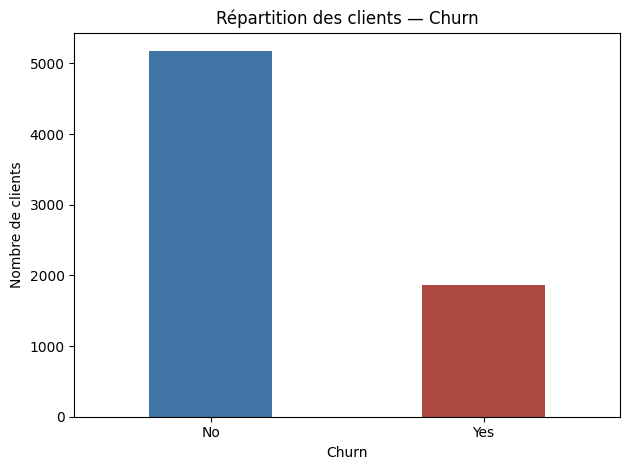

In [35]:
sns.countplot(
    data=df,
    x='Churn Label',
    hue='Churn Label',
    palette={'No': '#2E75B6', 'Yes': '#C0392B'},
    order=['No', 'Yes'],
    width=0.45,
    legend=False
)
plt.title('Répartition des clients — Churn')
plt.xlabel('Churn')
plt.ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

<b>Interprétation métier :</b> Le taux de churn observé montre que la fidélisation constitue un enjeu important pour l'entreprise.

#### <u> 4.2 Analyse démographique </u>

<b> Impact du genre sur le churn </b>

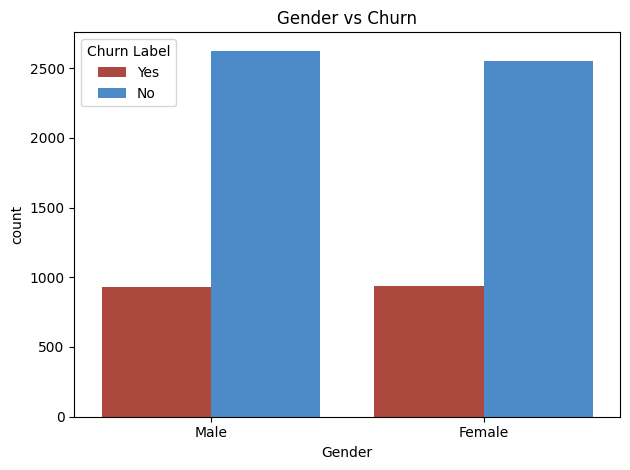

In [36]:
sns.countplot(data=df, x='Gender', hue='Churn Label',
              palette={'No': '#378ADD', 'Yes': '#C0392B'})
plt.title('Gender vs Churn')
plt.tight_layout()
plt.show()

<b>Interprétation métier :</b> Le genre n'est pas un facteur discriminant du churn dans ce dataset. Les actions de rétention ne doivent pas être segmentées par genre — d'autres variables (contrat, ancienneté, services) sont bien plus prédictives.

#### <u> 4.3 Analyse de l'ancienneté des clients / types de contrats</u>

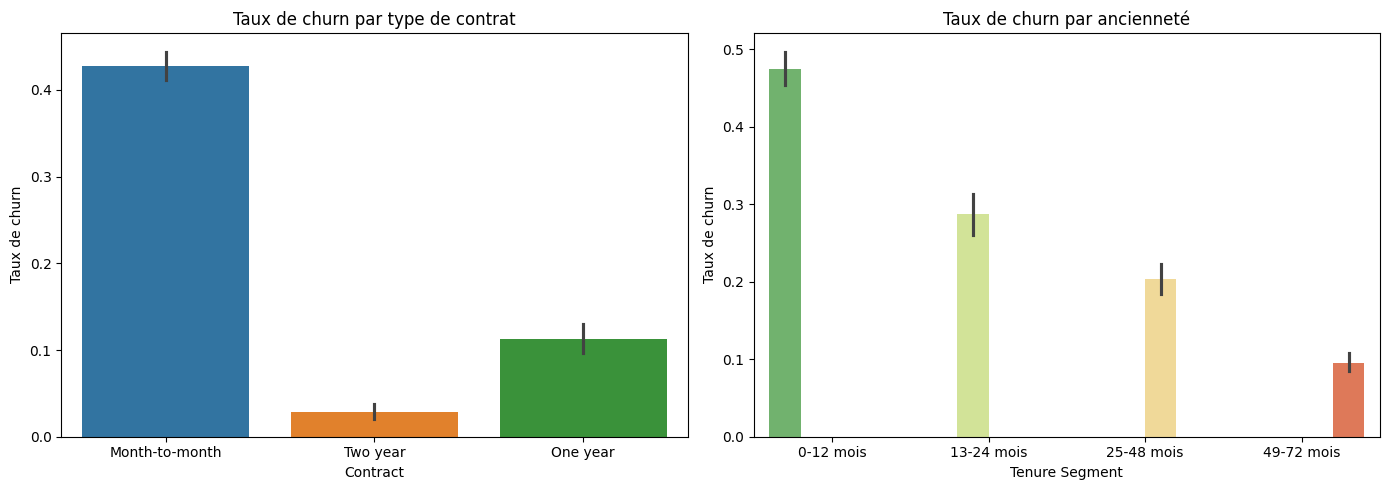

In [38]:
df['Tenure Segment'] = pd.cut(df['Tenure Months'], bins=[-1,12,24,48,72],
                               labels=['0-12 mois','13-24 mois','25-48 mois','49-72 mois'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Contract', y='Churn Value', estimator='mean', hue='Contract', ax=axes[0])
axes[0].set_title('Taux de churn par type de contrat')
axes[0].set_ylabel('Taux de churn')

sns.barplot(data=df, x='Tenure Segment', y='Churn Value', estimator='mean',
            palette='RdYlGn_r', hue='Tenure Segment', ax=axes[1])
axes[1].set_title('Taux de churn par ancienneté')
axes[1].set_ylabel('Taux de churn')

plt.tight_layout()
plt.show()

<b> Interprétation métier :</b> Beaucoup de clients partent très tôt ou restent très longtemps. Il y a peu de "clients moyens" — ce qui confirme que la première année est décisive pour la fidélisation.
Le type de contrat est le facteur le plus discriminant du dataset — convertir un client vers un contrat annuel réduit son risque de churn de façon drastique.

#### <u> 4.4 Analyse des méthodes de paiement </u>

<b> Influence du mode de paiement </b>

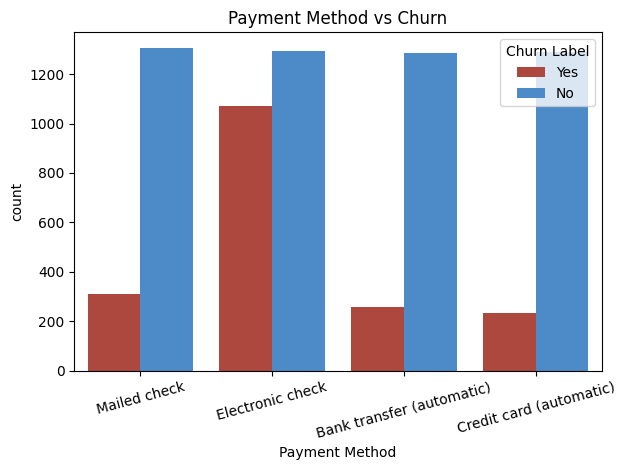

In [39]:
sns.countplot(data=df, x='Payment Method', hue='Churn Label',
              palette={'No': '#378ADD', 'Yes': '#C0392B'})
plt.title('Payment Method vs Churn')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<b> Interprétation métier :</b> Le chèque électronique est le mode de paiement le plus facile à arrêter — un seul clic suffit pour résilier. Le prélèvement automatique, lui, demande une démarche active pour être annulé, ce qui réduit naturellement les résiliations impulsives. Migrer les clients vers le prélèvement automatique est donc une action de rétention à faible coût et fort impact.

#### <u> 4.5 Analyse des services souscrits </u>

<b> Service de sécurité en ligne </b>

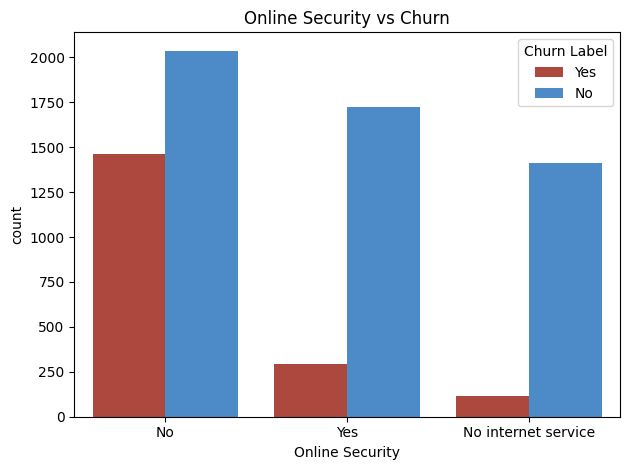

In [40]:
sns.countplot(data=df, x='Online Security', hue='Churn Label',
              palette={'No': '#378ADD', 'Yes': '#C0392B'},
              order=['No', 'Yes', 'No internet service'])
plt.title('Online Security vs Churn')
plt.tight_layout()
plt.show()

<b> Interprétation métier :</b> Les clients ne bénéficiant pas du service Online Security présentent un taux de résiliation près de trois fois supérieur à celui des clients qui y sont abonnés. Plus un client utilise de services complémentaires, plus son niveau d'engagement envers l'entreprise est élevé. Proposer l'option Online Security aux clients qui ne l'ont pas encore souscrite constitue donc un levier direct de fidélisation.

#### <u> 4.6 Analyse financière </u>

<b> Frais mensuels et churn </b>

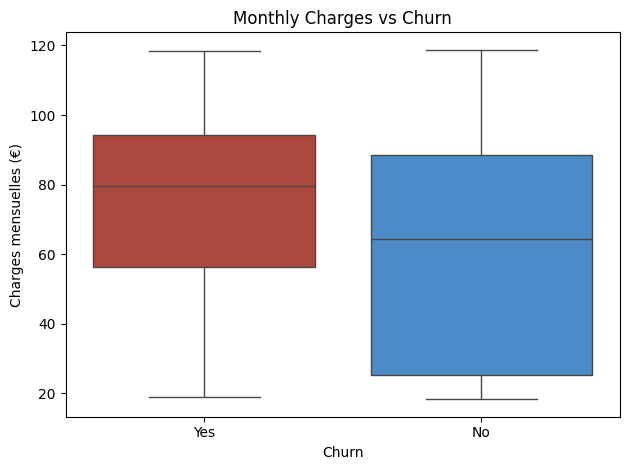

In [42]:
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges',
            hue='Churn Label',
            palette={'No': '#378ADD', 'Yes': '#C0392B'})
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Charges mensuelles (€)')
plt.tight_layout()
plt.show()

<b> Interprétation métier :</b>  Les churners paient en moyenne 80€/mois contre 64€ pour les non-churners. Le churn explose dans les tranches 65-95€ et >95€.
Les clients qui paient le plus sont aussi ceux qui examinent le plus la valeur de leur abonnement. Si le prix est élevé mais que la satisfaction ne suit pas, la résiliation devient logique. La rétention des clients premium doit être une priorité.

#### <u> 4.7 Impact financier du churn

<b>Estimation des revenus perdus </b>

In [43]:
lost_revenue = df[df["Churn Value"] == 1]["Monthly Charges"].sum()

print(f"Revenu mensuel perdu  : {lost_revenue:,.0f} €")
print(f"Revenu annuel perdu   : {lost_revenue * 12:,.0f} €")
print(f"Nombre de clients perdus : {df['Churn Value'].sum()}")

Revenu mensuel perdu  : 139,131 €
Revenu annuel perdu   : 1,669,570 €
Nombre de clients perdus : 1869


<b> Observation :</b> Les 1 869 clients ayant quitté l'entreprise représentaient un revenu mensuel cumulé d'environ 139 131 €, soit un potentiel de 1,67 million d'euros sur une année.

<b> Interprétation métier :</b> Le churn a un impact financier important sur l'entreprise. Réduire le nombre de résiliations permettrait de préserver une part significative des revenus récurrents.

### <b> 5. Analyse statistique

##### <u> Test du Chi² — Relation entre variables catégorielles et Churn </u>

In [45]:
from scipy.stats import chi2_contingency

variables = ['Contract', 'Internet Service', 'Payment Method']
alpha = 0.05

for var in variables:
    table = pd.crosstab(df[var], df['Churn Label'])
    chi2, p, dof, _ = chi2_contingency(table)
    decision = "Dépendant du churn" if p < alpha else "Indépendant du churn"
    print(f"{'='*50}")
    print(f"Variable     : {var}")
    print(f"p-value      : {p:.2e}")
    print(f"Résultat     : {decision}")

print(f"{'='*50}")
print(f"\nSeuil utilisé : α = {alpha}")

Variable     : Contract
p-value      : 5.86e-258
Résultat     : Dépendant du churn
Variable     : Internet Service
p-value      : 9.57e-160
Résultat     : Dépendant du churn
Variable     : Payment Method
p-value      : 3.68e-140
Résultat     : Dépendant du churn

Seuil utilisé : α = 0.05


<b> Interprétation :</b> Les trois variables ont une p-value très inférieure à 0.05. 
Le type de contrat, le service internet et le mode de paiement ont chacun une influence réelle et mesurable sur le churn. 

##### <u> T-Test — Les clients qui partent paient-ils plus cher ? </u>

In [46]:
from scipy.stats import ttest_ind

variables = ['Monthly Charges', 'Tenure Months']
alpha = 0.05

for var in variables:
    churners     = df[df['Churn Value'] == 1][var]
    non_churners = df[df['Churn Value'] == 0][var]
    t, p = ttest_ind(churners, non_churners)
    decision = " Différence significative" if p < alpha else " Différence non significative"
    print(f"{'='*50}")
    print(f"Variable       : {var}")
    print(f"Moyenne Churners     : {churners.mean():.2f}")
    print(f"Moyenne Non-Churners : {non_churners.mean():.2f}")
    print(f"p-value        : {p:.2e}")
    print(f"Résultat       : {decision}")

print(f"{'='*50}")
print(f"\nSeuil utilisé : α = {alpha}")

Variable       : Monthly Charges
Moyenne Churners     : 74.44
Moyenne Non-Churners : 61.27
p-value        : 2.71e-60
Résultat       :  Différence significative
Variable       : Tenure Months
Moyenne Churners     : 17.98
Moyenne Non-Churners : 37.57
p-value        : 8.00e-205
Résultat       :  Différence significative

Seuil utilisé : α = 0.05


<b> Interprétation : </b>

Les clients qui ont quitté paient 13€ de plus par mois — un tarif élevé sans valeur perçue en retour pousse naturellement à la résiliation.
Les clients qui ont quitté ont en moyenne 2x moins d'ancienneté — plus un client reste longtemps, plus il devient fidèle et difficile à perdre.

Les deux différences sont confirmées statistiquement (p ≪ 0.05)

### <b> 6. Exportation du dataset nettoyé 

In [47]:
df.to_excel('churn_clean.xlsx', index=False)

### <b> 7. Synthèse des principaux résultats

<b> Principaux enseignements : </b>

    Les contrats mensuels présentent le risque de churn le plus élevé.
    Les nouveaux clients sont plus susceptibles de quitter l'entreprise.
    Les services de sécurité et de support technique réduisent significativement le churn.
    Les clients ayant des frais mensuels élevés présentent un risque plus important de résiliation.
    Le churn représente une perte financière significative pour l'entreprise.

<b> Recommandations : </b>

    Encourager les contrats longue durée.
    Renforcer les programmes de fidélisation durant les premiers mois.
    Promouvoir les services à valeur ajoutée.
    Mettre en place des campagnes ciblées pour les clients à risque.
